Price (Quadratic basis): 1087.4639
Price (Rational basis): 1092.5018
Benchmark price (Trinomial tree): 1006.9537
Percent error Quadratic: 7.9954%
Percent error Rational: 8.4957%


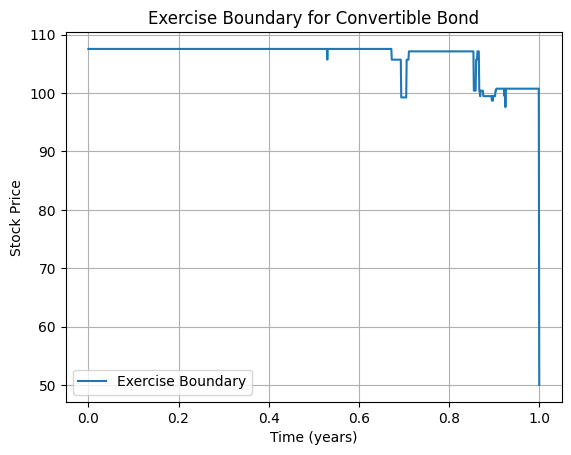

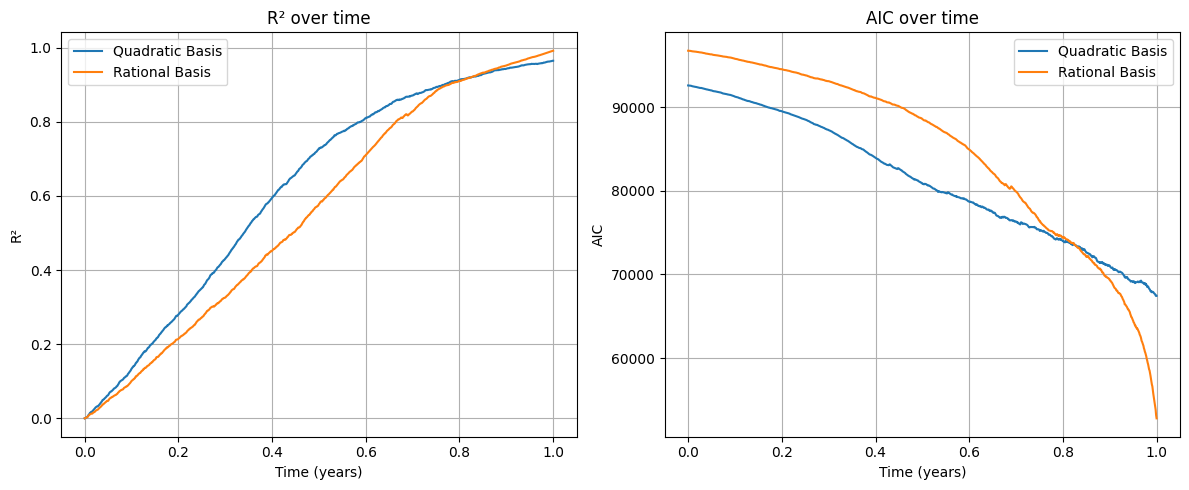

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Parameters
face_value = 1000
conversion_price = 50
conversion_ratio = face_value / conversion_price
r = 0.05
T = 1.0
M = 1000
dt = T / M
coupon_rate = 0.04
N = 10000
sigma = 0.2
S0 = 50

def quadratic_basis(S):
    return np.vstack([np.ones(len(S)), S, S**2]).T

def rational_basis(S):
    return np.vstack([
        np.ones(len(S)),
        S,
        S**2,
        1 / (1 + S),
        1 / (1 + S**2)
    ]).T

# Simulate GBM paths
np.random.seed(0)
Z = np.random.standard_normal((N, M))
S = np.zeros((N, M + 1))
S[:, 0] = S0
for t in range(1, M + 1):
    S[:, t] = S[:, t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, t-1])

# Initialize bond values at maturity
bond_values_quad = np.maximum(face_value, conversion_ratio * S[:, -1])
bond_values_rat = bond_values_quad.copy()

exercise_boundary = np.zeros(M + 1)

# Diagnostics storage
r2_quad = np.zeros(M)
aic_quad = np.zeros(M)
r2_rat = np.zeros(M)
aic_rat = np.zeros(M)

for t in range(M - 1, -1, -1):
    accrued_coupons = coupon_rate * dt * face_value
    discount_factor = np.exp(-r * dt)

    # Discount bond values from next step
    discounted_bond_values_quad = discount_factor * bond_values_quad + accrued_coupons
    discounted_bond_values_rat = discount_factor * bond_values_rat + accrued_coupons

    Y_quad = discounted_bond_values_quad
    Y_rat = discounted_bond_values_rat

    S_t = S[:, t]

    # Quadratic regression
    X_quad = quadratic_basis(S_t)
    coeffs_quad, _, _, _ = np.linalg.lstsq(X_quad, Y_quad, rcond=None)
    cont_val_quad = X_quad @ coeffs_quad
    ss_res_quad = np.sum((Y_quad - cont_val_quad) ** 2)
    ss_tot_quad = np.sum((Y_quad - np.mean(Y_quad)) ** 2)
    r2_quad[t] = 1 - ss_res_quad / ss_tot_quad if ss_tot_quad > 0 else 0
    n, k = X_quad.shape
    aic_quad[t] = n * np.log(ss_res_quad / n) + 2 * k if ss_res_quad > 0 else np.nan

    # Rational regression
    X_rat = rational_basis(S_t)
    coeffs_rat, _, _, _ = np.linalg.lstsq(X_rat, Y_rat, rcond=None)
    cont_val_rat = X_rat @ coeffs_rat
    ss_res_rat = np.sum((Y_rat - cont_val_rat) ** 2)
    ss_tot_rat = np.sum((Y_rat - np.mean(Y_rat)) ** 2)
    r2_rat[t] = 1 - ss_res_rat / ss_tot_rat if ss_tot_rat > 0 else 0
    n, k = X_rat.shape
    aic_rat[t] = n * np.log(ss_res_rat / n) + 2 * k if ss_res_rat > 0 else np.nan

    conversion_values = conversion_ratio * S_t

    # Exercise decision for quadratic basis
    exercise_quad = conversion_values >= cont_val_quad
    bond_values_quad = np.where(exercise_quad, conversion_values, discounted_bond_values_quad)

    # Exercise decision for rational basis
    exercise_rat = conversion_values >= cont_val_rat
    bond_values_rat = np.where(exercise_rat, conversion_values, discounted_bond_values_rat)

    # Exercise boundary estimation by union of hold states from both bases (optional)
    hold_indices = np.where(~(exercise_quad | exercise_rat))[0]
    exercise_boundary[t] = np.max(S[hold_indices]) if len(hold_indices) > 0 else 0

exercise_boundary[-1] = conversion_price

price_quad = np.mean(bond_values_quad) * np.exp(-r * dt)
price_rat = np.mean(bond_values_rat) * np.exp(-r * dt)

# Trinomial tree benchmark function
def trinomial_tree_price(S0, face_value, conversion_price, r, sigma, T, M_tree, coupon_rate):
    dt_tree = T / M_tree
    u = np.exp(sigma * np.sqrt(2 * dt_tree))
    d = 1 / u
    m = 1
    # Risk-neutral probabilities for trinomial tree
    pu = ((r * dt_tree * (1 - d) + (r * dt_tree)**2) / ((u - d) * (u - 1))) if u != d else 1/3
    pd = ((r * dt_tree * (u - 1) + (r * dt_tree)**2) / ((u - d) * (1 - d))) if u != d else 1/3
    pm = 1 - pu - pd

    # Stock prices at maturity
    stock_prices = np.array([S0 * u**max(0, i - M_tree) * d**max(0, M_tree - i) for i in range(2 * M_tree + 1)])

    # Initialize bond values at maturity
    bond_values = np.maximum(face_value, conversion_ratio * stock_prices)

    # Backward induction
    for t in range(M_tree - 1, -1, -1):
        new_bond_values = np.zeros(2 * t + 1)
        for i in range(2 * t + 1):
            cont_val = np.exp(-r * dt_tree) * (pu * bond_values[i + 2] + pm * bond_values[i + 1] + pd * bond_values[i])
            conv_val = conversion_ratio * S0 * u**max(0, i - t) * d**max(0, t - i)
            coupon = coupon_rate * dt_tree * face_value
            new_bond_values[i] = max(conv_val, cont_val + coupon)
        bond_values = new_bond_values

    return bond_values[0]

# Calculate benchmark price with trinomial tree (using less steps for speed)
benchmark_price = trinomial_tree_price(S0, face_value, conversion_price, r, sigma, T, 50, coupon_rate)

# Percent errors
percent_error_quad = abs(price_quad - benchmark_price) / benchmark_price * 100
percent_error_rat = abs(price_rat - benchmark_price) / benchmark_price * 100

# Print results
print(f"Price (Quadratic basis): {price_quad:.4f}")
print(f"Price (Rational basis): {price_rat:.4f}")
print(f"Benchmark price (Trinomial tree): {benchmark_price:.4f}")
print(f"Percent error Quadratic: {percent_error_quad:.4f}%")
print(f"Percent error Rational: {percent_error_rat:.4f}%")

# Plot exercise boundary
plt.plot(np.linspace(0, T, M + 1), exercise_boundary, label='Exercise Boundary')
plt.xlabel('Time (years)')
plt.ylabel('Stock Price')
plt.title('Exercise Boundary for Convertible Bond')
plt.grid(True)
plt.legend()
plt.show()

# Plot diagnostics
times = np.linspace(0, T, M)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(times, r2_quad, label='Quadratic Basis')
plt.plot(times, r2_rat, label='Rational Basis')
plt.xlabel('Time (years)')
plt.ylabel('R²')
plt.title('R² over time')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(times, aic_quad, label='Quadratic Basis')
plt.plot(times, aic_rat, label='Rational Basis')
plt.xlabel('Time (years)')
plt.ylabel('AIC')
plt.title('AIC over time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()